# 02 MLP

Self-contained MLP workflow. This notebook loads the common windows from preprocessing, extracts statistical features here, trains the MLP, evaluates it, and saves results.


## 1. MLP objective

The MLP does not use raw temporal windows. It receives one statistical feature vector per 30-second window.


## 2. Imports and configuration


In [143]:
from pathlib import Path
import sys

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\User\Documents\deep-learning\deep-learning


## 3. Shared training and evaluation imports


In [144]:
import importlib
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import src.config as config
import src.training as training_module

importlib.reload(config)
importlib.reload(training_module)
from src.config import (
    BATCH_SIZE,
    LEARNING_RATE,
    MAX_EPOCHS,
    PATIENCE,
    RANDOM_SEED,
    SEQUENCE_CHANNELS,
    WEIGHT_DECAY,
    WINDOW_SAMPLES,
)
from src.evaluation import (
    binary_metrics,
    collect_probabilities,
    per_subject_metrics,
    prediction_table,
    select_threshold,
)
from src.helpers import count_parameters, set_seed
from src.training import (
    pos_weight_from_labels,
    save_model_artifacts,
    train_with_early_stopping,
)

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 4. Load common windows and metadata

These are the same standardized temporal windows used by RNN and LSTM; the CNN 2D study derives scalograms from them.


In [145]:
sequence_dir = PROJECT_ROOT / "data" / "processed" / "sequence"
metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
preprocessing_dir = PROJECT_ROOT / "artifacts" / "preprocessing"

raw_paths = {
    "train": sequence_dir / "X_train_raw.pt",
    "validation": sequence_dir / "X_validation_raw.pt",
    "test": sequence_dir / "X_test_raw.pt",
}
missing_raw = [path.name for path in raw_paths.values() if not path.exists()]
if missing_raw:
    raise FileNotFoundError(
        "Raw sequence tensors are missing: "
        + ", ".join(missing_raw)
        + ". Rerun 01_preprocessing_and_splits.ipynb before this notebook."
    )

X_train_seq = torch.load(raw_paths["train"]).float()
y_train = torch.load(sequence_dir / "y_train.pt").float()
X_validation_seq = torch.load(raw_paths["validation"]).float()
y_validation = torch.load(sequence_dir / "y_validation.pt").float()
X_test_seq = torch.load(raw_paths["test"]).float()
y_test = torch.load(sequence_dir / "y_test.pt").float()

metadata_train = pd.read_csv(metadata_dir / "windows_train.csv")
metadata_validation = pd.read_csv(metadata_dir / "windows_validation.csv")
metadata_test = pd.read_csv(metadata_dir / "windows_test.csv")
with (preprocessing_dir / "sequence_channels.json").open("r", encoding="utf-8") as handle:
    saved_sequence_channels = json.load(handle)

assert saved_sequence_channels == SEQUENCE_CHANNELS
assert X_train_seq.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_validation_seq.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert X_test_seq.shape[1:] == (WINDOW_SAMPLES, len(SEQUENCE_CHANNELS))
assert torch.isfinite(X_train_seq).all()
assert torch.isfinite(X_validation_seq).all()
assert torch.isfinite(X_test_seq).all()
assert set(y_train.numpy().astype(int)).issubset({0, 1})
assert set(y_validation.numpy().astype(int)).issubset({0, 1})
assert set(y_test.numpy().astype(int)).issubset({0, 1})
assert len(metadata_train) == len(y_train)
assert len(metadata_validation) == len(y_validation)
assert len(metadata_test) == len(y_test)
assert np.array_equal(metadata_train["binary_label"].to_numpy(), y_train.numpy().astype(int))
assert np.array_equal(metadata_validation["binary_label"].to_numpy(), y_validation.numpy().astype(int))
assert np.array_equal(metadata_test["binary_label"].to_numpy(), y_test.numpy().astype(int))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_validation["subject_id"]))
assert set(metadata_train["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))
assert set(metadata_validation["subject_id"]).isdisjoint(set(metadata_test["subject_id"]))

X_train_seq.shape, X_validation_seq.shape, X_test_seq.shape


(torch.Size([1429, 960, 6]),
 torch.Size([287, 960, 6]),
 torch.Size([426, 960, 6]))

## 5. Explain why an MLP needs statistical features

Flattening `(960, 6)` raw samples would discard temporal structure poorly and create a large input. Instead, each window is summarized with statistical, BVP, EDA, temperature, and movement features.


## 6. Import shared feature-extraction functions


In [146]:
from src.preprocessing import extract_feature_table


## 7. Extract features from training windows


In [147]:
X_train_features_df = extract_feature_table(X_train_seq.numpy())
X_train_features_df.shape


(1429, 113)

## 8. Extract features from validation and test windows


In [148]:
X_validation_features_df = extract_feature_table(X_validation_seq.numpy())
X_test_features_df = extract_feature_table(X_test_seq.numpy())
X_validation_features_df.shape, X_test_features_df.shape


((287, 113), (426, 113))

## 9. Fit feature scaler using training features only


In [149]:
candidate_columns = list(X_train_features_df.columns)
exact_duplicate_mask = X_train_features_df[candidate_columns].T.duplicated()
exact_duplicate_columns = [
    column for column, is_duplicate in zip(candidate_columns, exact_duplicate_mask) if is_duplicate
]
candidate_columns = [column for column in candidate_columns if column not in exact_duplicate_columns]

constant_columns = [
    column for column in candidate_columns if X_train_features_df[column].nunique(dropna=False) <= 1
]
candidate_columns = [column for column in candidate_columns if column not in constant_columns]

correlation_matrix = X_train_features_df[candidate_columns].corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_correlation_columns = [
    column for column in upper_triangle.columns if (upper_triangle[column] > 0.95).any()
]
feature_columns = [column for column in candidate_columns if column not in high_correlation_columns]

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_features_df[feature_columns])

X_train = torch.tensor(feature_scaler.transform(X_train_features_df[feature_columns]), dtype=torch.float32)
X_validation = torch.tensor(feature_scaler.transform(X_validation_features_df[feature_columns]), dtype=torch.float32)
X_test = torch.tensor(feature_scaler.transform(X_test_features_df[feature_columns]), dtype=torch.float32)

artifact_dir = PROJECT_ROOT / "artifacts" / "preprocessing"
artifact_dir.mkdir(parents=True, exist_ok=True)
with (artifact_dir / "feature_columns.json").open("w", encoding="utf-8") as handle:
    json.dump(feature_columns, handle, indent=2)
joblib.dump(feature_scaler, artifact_dir / "mlp_feature_scaler.joblib")
with (artifact_dir / "feature_selection.json").open("w", encoding="utf-8") as handle:
    json.dump(
        {
            "removed_exact_duplicate_columns": exact_duplicate_columns,
            "removed_constant_columns": constant_columns,
            "removed_high_correlation_columns": high_correlation_columns,
            "correlation_threshold": 0.95,
        },
        handle,
        indent=2,
    )

feature_dir = PROJECT_ROOT / "data" / "processed" / "features"
feature_dir.mkdir(parents=True, exist_ok=True)
X_train_features_df.to_csv(feature_dir / "X_train_unscaled.csv", index=False)
X_validation_features_df.to_csv(feature_dir / "X_validation_unscaled.csv", index=False)
X_test_features_df.to_csv(feature_dir / "X_test_unscaled.csv", index=False)
pd.DataFrame(X_train.numpy(), columns=feature_columns).to_csv(feature_dir / "X_train.csv", index=False)
pd.DataFrame(X_validation.numpy(), columns=feature_columns).to_csv(feature_dir / "X_validation.csv", index=False)
pd.DataFrame(X_test.numpy(), columns=feature_columns).to_csv(feature_dir / "X_test.csv", index=False)
X_train.shape, X_validation.shape, X_test.shape, len(exact_duplicate_columns), len(constant_columns), len(high_correlation_columns)


(torch.Size([1429, 75]),
 torch.Size([287, 75]),
 torch.Size([426, 75]),
 0,
 0,
 38)

## 10. Create PyTorch datasets and DataLoaders


In [150]:
import importlib
import src.config as config

importlib.reload(config)
BATCH_SIZE = config.BATCH_SIZE

train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## 11. Define the MLP class


In [151]:
from src.models import MLPClassifier


## 12. Display model architecture


In [152]:
model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
model


MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=75, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 13. Define training loop


Training utilities above use raw logits with `BCEWithLogitsLoss`. The final model layer does not include a sigmoid.


## 14. Define validation loop


Validation collects probabilities with `torch.sigmoid(logits)` and uses validation data only to select a threshold.


## 15. Train without imbalance correction


In [153]:
import importlib
import src.config as config

importlib.reload(config)
LEARNING_RATE = config.LEARNING_RATE
WEIGHT_DECAY = config.WEIGHT_DECAY
MAX_EPOCHS = config.MAX_EPOCHS
PATIENCE = config.PATIENCE

set_seed(RANDOM_SEED)
unweighted_model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
unweighted_criterion = torch.nn.BCEWithLogitsLoss()
unweighted_optimizer = torch.optim.Adam(unweighted_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
unweighted_model, unweighted_history, unweighted_training_summary = train_with_early_stopping(
    unweighted_model,
    train_loader,
    validation_loader,
    unweighted_criterion,
    unweighted_optimizer,
    device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    verbose=True,
)
unweighted_history.tail()


Epoch 001/100 | train_loss=0.5281 | validation_loss=0.5041 | best_epoch=1 *
Epoch 002/100 | train_loss=0.2946 | validation_loss=0.3869 | best_epoch=2 *
Epoch 003/100 | train_loss=0.1974 | validation_loss=0.3879 | best_epoch=2
Epoch 004/100 | train_loss=0.1436 | validation_loss=0.3368 | best_epoch=4 *
Epoch 005/100 | train_loss=0.1220 | validation_loss=0.3315 | best_epoch=5 *
Epoch 006/100 | train_loss=0.0887 | validation_loss=0.3383 | best_epoch=5
Epoch 007/100 | train_loss=0.0687 | validation_loss=0.3637 | best_epoch=5
Epoch 008/100 | train_loss=0.0586 | validation_loss=0.3446 | best_epoch=5
Epoch 009/100 | train_loss=0.0464 | validation_loss=0.3446 | best_epoch=5
Epoch 010/100 | train_loss=0.0437 | validation_loss=0.3684 | best_epoch=5
Epoch 011/100 | train_loss=0.0427 | validation_loss=0.3197 | best_epoch=11 *
Epoch 012/100 | train_loss=0.0402 | validation_loss=0.3646 | best_epoch=11
Epoch 013/100 | train_loss=0.0247 | validation_loss=0.3677 | best_epoch=11
Epoch 014/100 | train_los

,epoch,train_loss,validation_loss
16,17,0.021203,0.412104
17,18,0.018775,0.457092
18,19,0.013060,0.421601
19,20,0.010948,0.477807
20,21,0.013462,0.485099


## 16. Train with class weights


In [154]:
import importlib
import src.config as config

importlib.reload(config)
LEARNING_RATE = config.LEARNING_RATE
WEIGHT_DECAY = config.WEIGHT_DECAY
MAX_EPOCHS = config.MAX_EPOCHS
PATIENCE = config.PATIENCE

set_seed(RANDOM_SEED)
model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
pos_weight = pos_weight_from_labels(y_train, device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model, history, weighted_training_summary = train_with_early_stopping(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    verbose=True,
)
history.tail()


Epoch 001/100 | train_loss=0.6920 | validation_loss=0.6481 | best_epoch=1 *
Epoch 002/100 | train_loss=0.3573 | validation_loss=0.5352 | best_epoch=2 *
Epoch 003/100 | train_loss=0.2477 | validation_loss=0.5291 | best_epoch=3 *
Epoch 004/100 | train_loss=0.1842 | validation_loss=0.4913 | best_epoch=4 *
Epoch 005/100 | train_loss=0.1603 | validation_loss=0.4996 | best_epoch=4
Epoch 006/100 | train_loss=0.1184 | validation_loss=0.4996 | best_epoch=4
Epoch 007/100 | train_loss=0.0941 | validation_loss=0.5233 | best_epoch=4
Epoch 008/100 | train_loss=0.0820 | validation_loss=0.5380 | best_epoch=4
Epoch 009/100 | train_loss=0.0661 | validation_loss=0.5088 | best_epoch=4
Epoch 010/100 | train_loss=0.0623 | validation_loss=0.5542 | best_epoch=4
Epoch 011/100 | train_loss=0.0599 | validation_loss=0.5284 | best_epoch=4
Epoch 012/100 | train_loss=0.0558 | validation_loss=0.5293 | best_epoch=4
Epoch 013/100 | train_loss=0.0394 | validation_loss=0.5780 | best_epoch=4
Epoch 014/100 | train_loss=0.0

,epoch,train_loss,validation_loss
9,10,0.062314,0.554179
10,11,0.059929,0.528382
11,12,0.055785,0.529324
12,13,0.039422,0.577979
13,14,0.034332,0.599871


In [155]:
unweighted_validation_probabilities, unweighted_validation_true = collect_probabilities(unweighted_model, validation_loader, device)
unweighted_threshold, _ = select_threshold(unweighted_validation_true, unweighted_validation_probabilities)
unweighted_validation_metrics = binary_metrics(
    unweighted_validation_true,
    unweighted_validation_probabilities,
    unweighted_threshold,
)

weighted_validation_probabilities, weighted_validation_true = collect_probabilities(model, validation_loader, device)
weighted_threshold, _ = select_threshold(weighted_validation_true, weighted_validation_probabilities)
weighted_validation_metrics = binary_metrics(
    weighted_validation_true,
    weighted_validation_probabilities,
    weighted_threshold,
)

unweighted_best_epoch = int(unweighted_history.loc[unweighted_history["validation_loss"].idxmin(), "epoch"])
weighted_best_epoch = int(history.loc[history["validation_loss"].idxmin(), "epoch"])

validation_variant_comparison = pd.DataFrame(
    [
        {
            "method": "no_correction",
            "best_epoch": unweighted_best_epoch,
            "threshold": unweighted_threshold,
            "macro_f1": unweighted_validation_metrics["macro_f1"],
            "weighted_f1": unweighted_validation_metrics["weighted_f1"],
            "stress_precision": unweighted_validation_metrics["stress_precision"],
            "stress_recall": unweighted_validation_metrics["stress_recall"],
            "average_precision": unweighted_validation_metrics["average_precision"],
        },
        {
            "method": "class_weight",
            "best_epoch": weighted_best_epoch,
            "threshold": weighted_threshold,
            "macro_f1": weighted_validation_metrics["macro_f1"],
            "weighted_f1": weighted_validation_metrics["weighted_f1"],
            "stress_precision": weighted_validation_metrics["stress_precision"],
            "stress_recall": weighted_validation_metrics["stress_recall"],
            "average_precision": weighted_validation_metrics["average_precision"],
        },
    ]
)
display(validation_variant_comparison)

if weighted_validation_metrics["macro_f1"] >= unweighted_validation_metrics["macro_f1"]:
    selected_model = model
    selected_history = history
    selected_threshold = weighted_threshold
    selected_validation_probabilities = weighted_validation_probabilities
    selected_validation_true = weighted_validation_true
    selected_validation_metrics = weighted_validation_metrics
    selected_method = "class_weight"
    selected_best_epoch = weighted_best_epoch
    selected_training_summary = weighted_training_summary
else:
    selected_model = unweighted_model
    selected_history = unweighted_history
    selected_threshold = unweighted_threshold
    selected_validation_probabilities = unweighted_validation_probabilities
    selected_validation_true = unweighted_validation_true
    selected_validation_metrics = unweighted_validation_metrics
    selected_method = "no_correction"
    selected_best_epoch = unweighted_best_epoch
    selected_training_summary = unweighted_training_summary

model = selected_model
history = selected_history
threshold = selected_threshold
validation_probabilities = selected_validation_probabilities
validation_true = selected_validation_true
validation_metrics = {
    **selected_validation_metrics,
    "selected_imbalance_method": selected_method,
    "best_validation_epoch": selected_best_epoch,
    "variant_comparison": validation_variant_comparison.to_dict(orient="records"),
}

threshold, selected_method, validation_metrics


,method,best_epoch,threshold,macro_f1,weighted_f1,stress_precision,stress_recall,average_precision
0,no_correction,11,0.61,0.906061,0.920488,0.846154,0.895349,0.886327
1,class_weight,4,0.76,0.859799,0.881918,0.795455,0.813953,0.832100


(0.61,
 'no_correction',
 {'macro_f1': 0.9060609941795101,
  'weighted_f1': 0.9204878832230725,
  'non_stress_precision': 0.9540816326530612,
  'non_stress_recall': 0.9303482587064676,
  'stress_precision': 0.8461538461538461,
  'stress_recall': 0.8953488372093024,
  'confusion_matrix': [[187, 14], [9, 77]],
  'roc_auc': 0.9364225384704385,
  'average_precision': 0.8863270265727157,
  'selected_imbalance_method': 'no_correction',
  'best_validation_epoch': 11,
  'variant_comparison': [{'method': 'no_correction',
    'best_epoch': 11,
    'threshold': 0.61,
    'macro_f1': 0.9060609941795101,
    'weighted_f1': 0.9204878832230725,
    'stress_precision': 0.8461538461538461,
    'stress_recall': 0.8953488372093024,
    'average_precision': 0.8863270265727157},
   {'method': 'class_weight',
    'best_epoch': 4,
    'threshold': 0.76,
    'macro_f1': 0.8597988505747127,
    'weighted_f1': 0.8819177780447757,
    'stress_precision': 0.7954545454545454,
    'stress_recall': 0.813953488372093

## 18. Evaluate test data


In [156]:
inference_start_time = time.perf_counter()
test_probabilities, test_true = collect_probabilities(model, test_loader, device)
inference_time_seconds = time.perf_counter() - inference_start_time
test_metrics = binary_metrics(test_true, test_probabilities, threshold)
test_metrics = {**test_metrics, "inference_time_seconds": inference_time_seconds}
test_metrics


{'macro_f1': 0.8564226861047967,
 'weighted_f1': 0.8839947583856924,
 'non_stress_precision': 0.8768768768768769,
 'non_stress_recall': 0.9798657718120806,
 'stress_precision': 0.9354838709677419,
 'stress_recall': 0.6796875,
 'confusion_matrix': [[292, 6], [41, 87]],
 'roc_auc': 0.9770606124161074,
 'average_precision': 0.9468646125889775,
 'inference_time_seconds': 0.026060099946334958}

## 19. Evaluate by subject


In [157]:
subject_metrics = per_subject_metrics(metadata_test, test_true, test_probabilities, threshold)
subject_metrics


,subject_id,n_windows,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,S11,144,0.983422,0.986018,0.980392,1.000000,1.000000,0.954545,"[[100, 0], [2, 42]]",1.000000,1.000000
1,S14,144,0.912088,0.927757,0.909091,1.000000,1.000000,0.772727,"[[100, 0], [10, 34]]",0.990909,0.982972
2,S2,138,0.613074,0.708525,0.760331,0.938776,0.647059,0.275000,"[[92, 6], [29, 11]]",0.878827,0.672249


## 20. Plot confusion matrix


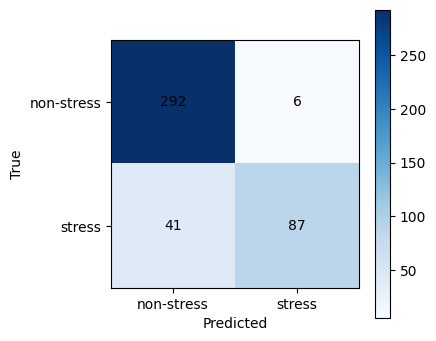

In [158]:
cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["non-stress", "stress"])
ax.set_yticks([0, 1], labels=["non-stress", "stress"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.show()


## 21. Plot ROC and precision-recall curves


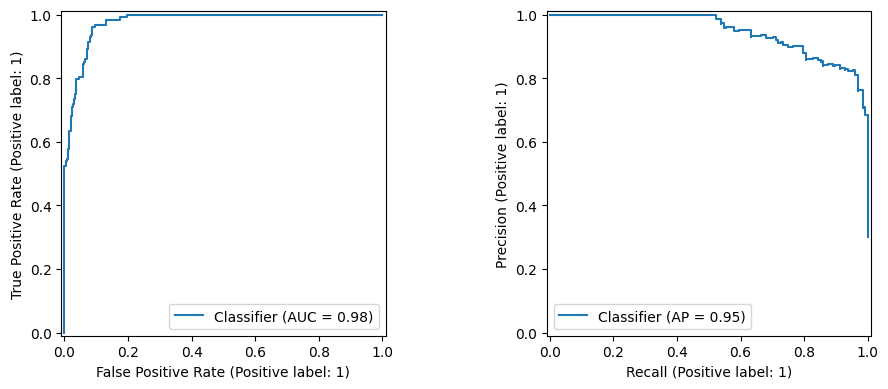

In [159]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(test_true, test_probabilities, ax=axes[0])
PrecisionRecallDisplay.from_predictions(test_true, test_probabilities, ax=axes[1])
plt.tight_layout()
plt.show()


## 22. SHAP analysis

SHAP explains model behavior, not physiological causality.


Model output shape for SHAP: torch.Size([4, 1])


C:\Users\User\AppData\Local\Temp\ipykernel_27468\3987686164.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values, samples.numpy(), feature_names=feature_columns, show=False)


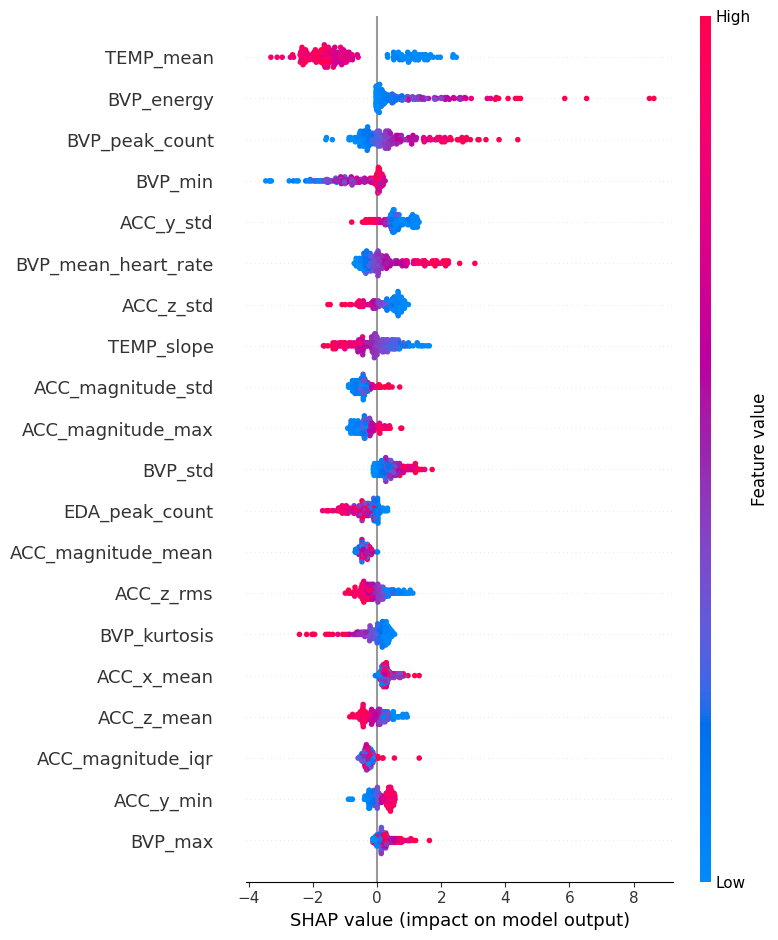

C:\Users\User\AppData\Local\Temp\ipykernel_27468\3987686164.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values, samples.numpy(), feature_names=feature_columns, plot_type="bar", show=False)


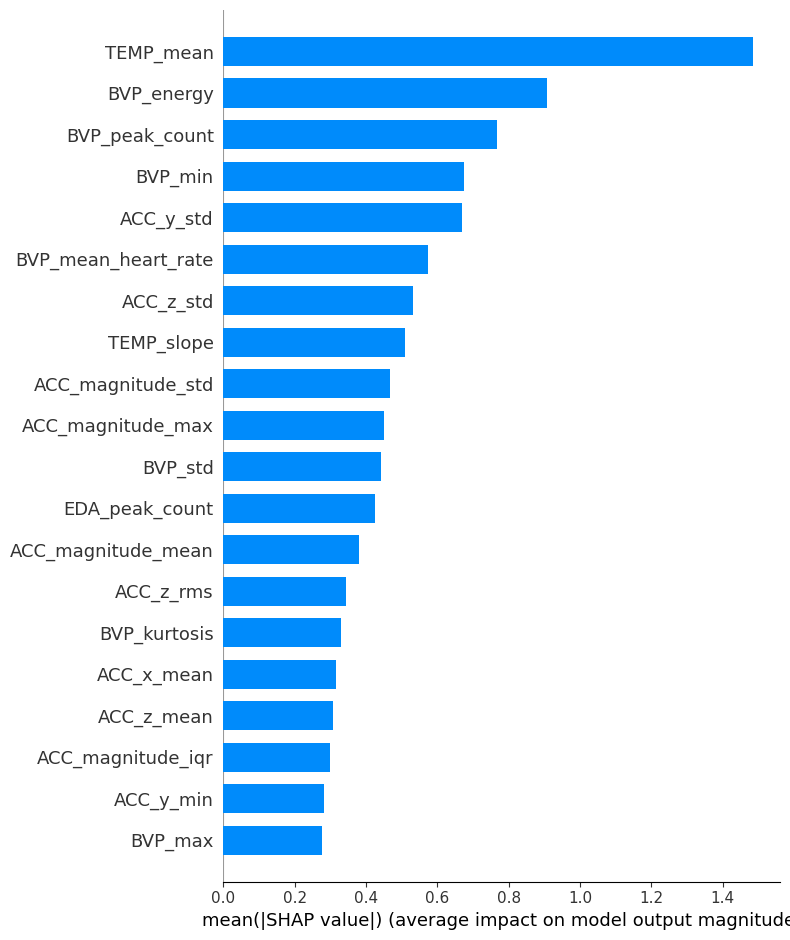

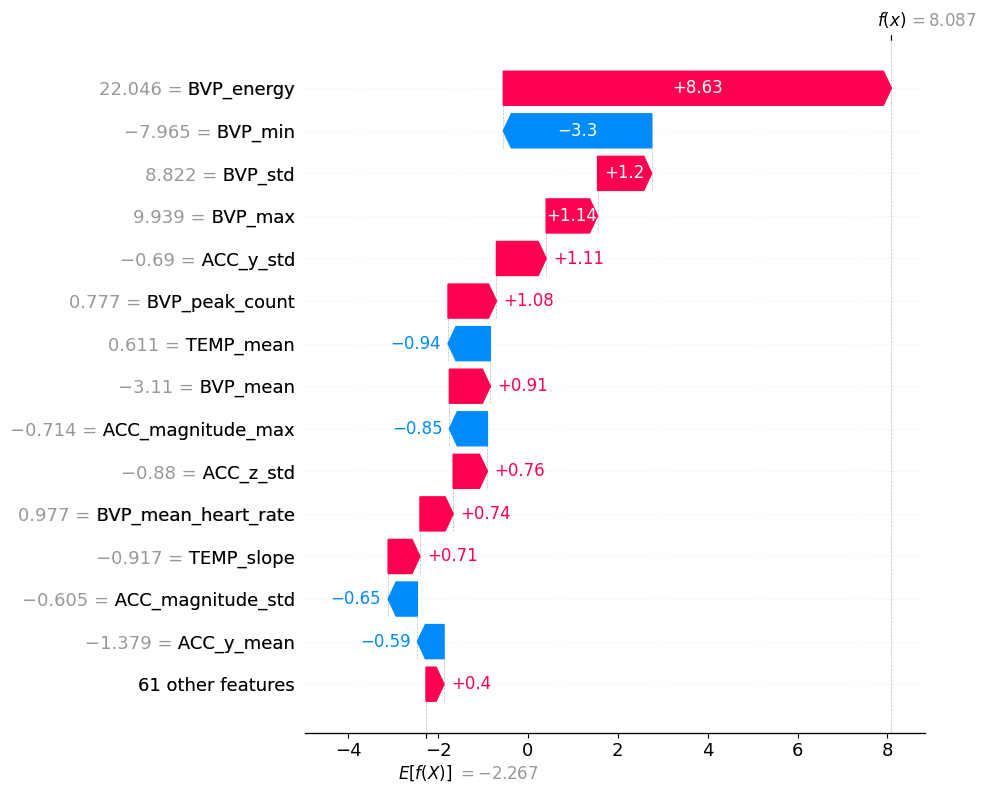

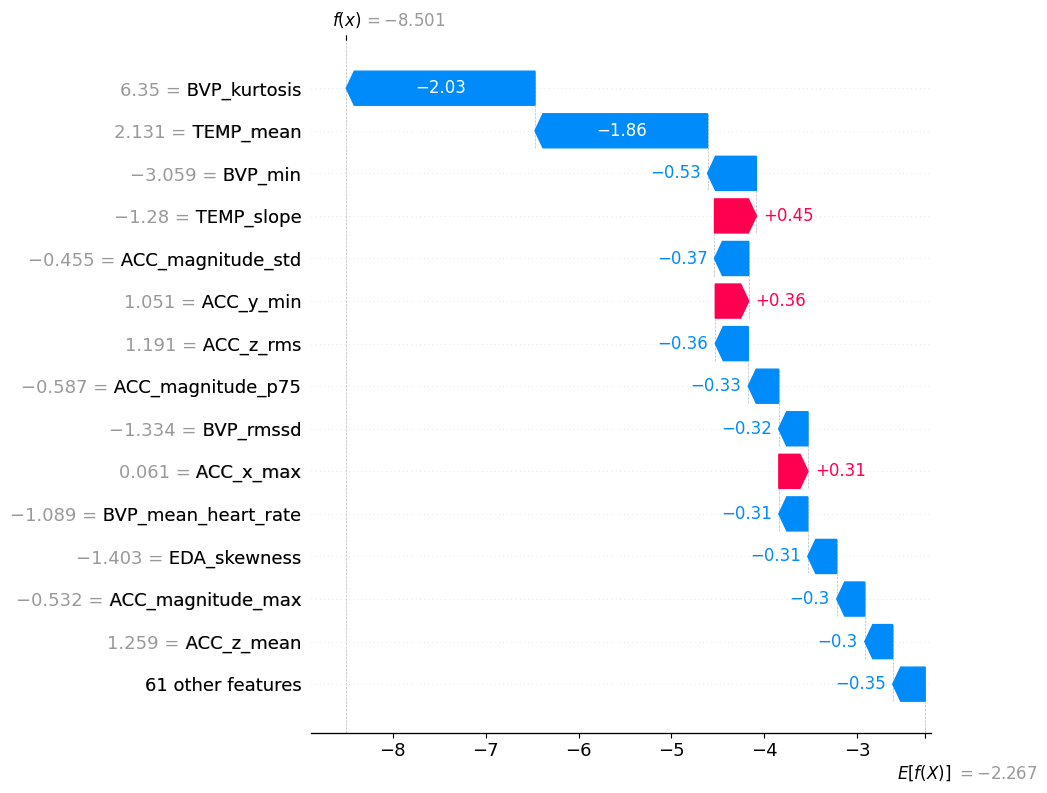

In [160]:
try:
    import shap

    shap_dir = PROJECT_ROOT / "reports" / "figures" / "shap"
    shap_dir.mkdir(parents=True, exist_ok=True)

    model.eval()
    shap_model = model.to("cpu")
    background = X_train[: min(100, len(X_train))]
    explain_count = min(200, len(X_validation))
    samples = X_validation[:explain_count]

    with torch.no_grad():
        print("Model output shape for SHAP:", shap_model(background[:4]).shape)

    explainer = shap.DeepExplainer(shap_model, background)
    shap_values = explainer.shap_values(samples)
    values = shap_values[0] if isinstance(shap_values, list) else shap_values
    values = np.asarray(values).squeeze()

    shap.summary_plot(values, samples.numpy(), feature_names=feature_columns, show=False)
    plt.tight_layout()
    plt.savefig(shap_dir / "mlp_shap_summary.png", dpi=200, bbox_inches="tight")
    plt.show()

    shap.summary_plot(values, samples.numpy(), feature_names=feature_columns, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(shap_dir / "mlp_shap_bar.png", dpi=200, bbox_inches="tight")
    plt.show()

    probs = validation_probabilities[:explain_count]
    for title, index in [("highest_stress_score", int(np.argmax(probs))), ("lowest_stress_score", int(np.argmin(probs)))]:
        explanation = shap.Explanation(
            values=values[index],
            base_values=np.asarray(explainer.expected_value).reshape(-1)[0],
            data=samples[index].numpy(),
            feature_names=feature_columns,
        )
        shap.plots.waterfall(explanation, max_display=15, show=False)
        plt.savefig(shap_dir / f"mlp_shap_waterfall_{title}.png", dpi=200, bbox_inches="tight")
        plt.show()

    model.to(device)
except ImportError:
    print("Install shap to run SHAP explanations: pip install shap")


## 23. Save model and results


In [161]:
artifact_dir = PROJECT_ROOT / "artifacts" / "models" / "mlp"
test_predictions = prediction_table(metadata_test, test_true, test_probabilities, threshold)

save_model_artifacts(
    artifact_dir=artifact_dir,
    model=model,
    model_config={
        "model": "MLPClassifier",
        "input_dim": int(X_train.shape[1]),
        "dropout": 0.3,
        "parameter_count": count_parameters(model),
        "selected_imbalance_method": selected_method,
        "best_validation_epoch": selected_best_epoch,
        "random_seed": RANDOM_SEED,
        "uses_class_weighting": selected_method == "class_weight",
        "input_representation": "statistical_features_extracted_from_raw_windows",
        "removed_exact_duplicate_features": exact_duplicate_columns,
        "removed_constant_features": constant_columns,
        "removed_high_correlation_features": high_correlation_columns,
    },
    threshold=threshold,
    history=history,
    validation_metrics=validation_metrics,
    test_metrics=test_metrics,
    per_subject=subject_metrics,
    test_predictions=test_predictions,
    training_summary={**selected_training_summary, "selected_imbalance_method": selected_method, "inference_time_seconds": inference_time_seconds},
)
artifact_dir


WindowsPath('C:/Users/User/Documents/deep-learning/deep-learning/artifacts/models/mlp')

## 24. Conclusion

The MLP is evaluated on the same windows and subjects as the sequence models, but it receives statistical features instead of raw temporal sequences.
